# TYPE-EXP-002 — Multi-source FTR Vehicle Type Classifier

Amaç: FTR `arac_bilgisi.tip` alanı için 7 sınıfı **doğrudan** kapsayan daha güçlü araç tipi classifier eğitmek.

Zorunlu FTR tip sınıfları:

```text
sedan, suv, hatchback, pickup, minibus, panelvan, kamyon
```

Bu notebook, `TYPE-EXP-001` sonucunda görülen iki sorunu düzeltmek için açıldı:

1. `kamyon` sınıfı `0` örnekte kaldığı için model o sınıfı öğrenemedi.
2. Stanford model isimlerinden tek başına type üretmek `suv/hatchback/panelvan` karışmasına açık kaldı.

EXP-002 yaklaşımı:

- **Ana kaynak 1 — Stanford Cars**: sedan/SUV/hatchback/pickup/minibus/panelvan için fine-grained model isimlerinden konservatif mapping.
- **Ana kaynak 2 — Car Body Type Kaggle**: sedan/SUV/hatchback/pickup/panelvan tarafını doğrudan body-type klasörlerinden besler.
- **Ana kaynak 3 — MIO-TCD classification subset/mirror**: pickup/work-van/truck sınıflarıyla `pickup`, `panelvan`, `kamyon` desteği sağlar.
- **Manual FTR klasörleri**: eksik kalan sınıflar için doğrudan `sedan/suv/hatchback/pickup/minibus/panelvan/kamyon` klasörleriyle veri eklenir.

Önemli: Bu notebook, erişilemeyen veya eksik kaynak varsa sessizce yanlış eğitim yapmaz. `STRICT_CLASS_COVERAGE=True` iken her FTR sınıfında minimum örnek yoksa eğitim başlamadan durur.

## Senin Yapman Gerekenler

1. Colab Runtime: GPU seç. L4 yeterli, A100 daha hızlıdır.
2. Colab Secrets içine Kaggle bilgilerini ekle:
   - `KAGGLE_USERNAME`
   - `KAGGLE_KEY`
   - küçük harfli `kaggle_username`, `kaggle_key` de desteklenir.
3. Kaggle indirme çalışmazsa zip dosyalarını ilgili Drive klasörlerine koy:

```text
/content/drive/MyDrive/anomali-road-safety-ai/datasets/type_exp_002/stanford_cars/
/content/drive/MyDrive/anomali-road-safety-ai/datasets/type_exp_002/car_body_type/
/content/drive/MyDrive/anomali-road-safety-ai/datasets/type_exp_002/mio_tcd/
```

4. Eksik sınıflar için manual klasörler:

```text
/content/drive/MyDrive/anomali-road-safety-ai/datasets/type_exp_002/manual/sedan/
/content/drive/MyDrive/anomali-road-safety-ai/datasets/type_exp_002/manual/suv/
/content/drive/MyDrive/anomali-road-safety-ai/datasets/type_exp_002/manual/hatchback/
/content/drive/MyDrive/anomali-road-safety-ai/datasets/type_exp_002/manual/pickup/
/content/drive/MyDrive/anomali-road-safety-ai/datasets/type_exp_002/manual/minibus/
/content/drive/MyDrive/anomali-road-safety-ai/datasets/type_exp_002/manual/panelvan/
/content/drive/MyDrive/anomali-road-safety-ai/datasets/type_exp_002/manual/kamyon/
```

5. Çalıştırma sırası: hücreleri baştan sona çalıştır. Dataset coverage tablosunda tüm 7 sınıfın dolduğunu görmeden eğitim hücresine geçme.

In [ ]:
# Cell 1 — Runtime setup + dependencies
import os
import sys
import json
import math
import time
import random
import shutil
import zipfile
import subprocess
from pathlib import Path
from collections import Counter, defaultdict

IN_COLAB = 'google.colab' in sys.modules

def run_cmd(cmd, check=True, capture_output=False):
    print('+', ' '.join(map(str, cmd)))
    return subprocess.run(cmd, check=check, text=True, capture_output=capture_output)

if IN_COLAB:
    run_cmd([sys.executable, '-m', 'pip', 'install', '-q', 'kaggle', 'scikit-learn', 'pandas', 'matplotlib', 'seaborn', 'tqdm', 'scipy'])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.models as models
import torchvision.transforms as T

from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit

print('IN_COLAB:', IN_COLAB)
print('Python:', sys.version)
print('Torch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

+ /usr/bin/python3 -m pip install -q kaggle scikit-learn pandas matplotlib seaborn tqdm scipy
IN_COLAB: True
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Torch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA L4


In [ ]:
# Cell 2 — Drive mount + experiment configuration
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

PROJECT_ROOT = Path('/content/drive/MyDrive/anomali-road-safety-ai') if IN_COLAB else Path.cwd()
LOCAL_ROOT = Path('/content/anomali-road-safety-ai-work') if IN_COLAB else Path.cwd() / '.local_colab_work'
EXP_ID = 'TYPE-EXP-002'

FTR_TYPE_LABELS = ['sedan', 'suv', 'hatchback', 'pickup', 'minibus', 'panelvan', 'kamyon']

# Main source toggles. Keep these True for the intended EXP-002 run.
ENABLE_STANFORD = True
ENABLE_CAR_BODY_KAGGLE = True
ENABLE_MIO_TCD = True
ENABLE_MANUAL_FOLDERS = True

# Safety gates.
STRICT_CLASS_COVERAGE = True
MIN_IMAGES_PER_CLASS = 150
MAX_IMAGES_PER_CLASS = 4500
MAX_IMAGES_PER_SOURCE_CLASS = 1800

# Training controls.
SMOKE_MODE = False
IMAGE_SIZE = 224
BATCH_SIZE = 128 if torch.cuda.is_available() else 16
NUM_WORKERS = 2 if IN_COLAB else 0
EPOCHS = 22
PATIENCE = 6
LR = 3e-4
WEIGHT_DECAY = 1e-4
UNFREEZE_BACKBONE = True
RUN_MOBILENETV3_LARGE = True
RUN_EFFICIENTNET_B0 = True

# Kaggle dataset candidates. Slugs are tried in order; failed sources are reported and skipped.
STANFORD_KAGGLE_SLUGS = [
    'eduardo4jesus/stanford-cars-dataset',
    'jessicali9530/stanford-cars-dataset',
]
CAR_BODY_KAGGLE_SLUGS = [
    'ademboukhris/cars-body-type-cropped',
    'mayurmahurkar/stanford-car-body-type-data',
    'darshan1504/car-body-style-dataset',
]
MIO_TCD_KAGGLE_SLUGS = [
    'yash88600/miotcd-dataset-50000-imagesclassification',
]

DRIVE_DATA_ROOT = PROJECT_ROOT / 'datasets' / 'type_exp_002'
DRIVE_STANFORD_ROOT = DRIVE_DATA_ROOT / 'stanford_cars'
DRIVE_CAR_BODY_ROOT = DRIVE_DATA_ROOT / 'car_body_type'
DRIVE_MIO_ROOT = DRIVE_DATA_ROOT / 'mio_tcd'
DRIVE_MANUAL_ROOT = DRIVE_DATA_ROOT / 'manual'
DRIVE_METADATA_ROOT = DRIVE_DATA_ROOT / 'metadata'
DRIVE_RUN_ROOT = PROJECT_ROOT / 'runs' / 'vehicle_type' / EXP_ID
DRIVE_CKPT_ROOT = PROJECT_ROOT / 'models' / 'checkpoints' / 'vehicle_type'

LOCAL_DATA_ROOT = LOCAL_ROOT / 'datasets' / 'type_exp_002'
LOCAL_STANFORD_EXTRACT = LOCAL_DATA_ROOT / 'stanford_cars' / 'extracted'
LOCAL_CAR_BODY_EXTRACT = LOCAL_DATA_ROOT / 'car_body_type' / 'extracted'
LOCAL_MIO_EXTRACT = LOCAL_DATA_ROOT / 'mio_tcd' / 'extracted'
LOCAL_MANUAL_ROOT = LOCAL_DATA_ROOT / 'manual'

for p in [DRIVE_STANFORD_ROOT, DRIVE_CAR_BODY_ROOT, DRIVE_MIO_ROOT, DRIVE_MANUAL_ROOT, DRIVE_METADATA_ROOT, DRIVE_RUN_ROOT, DRIVE_CKPT_ROOT,
          LOCAL_STANFORD_EXTRACT, LOCAL_CAR_BODY_EXTRACT, LOCAL_MIO_EXTRACT, LOCAL_MANUAL_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT:', PROJECT_ROOT)
print('DRIVE_DATA_ROOT:', DRIVE_DATA_ROOT)
print('LOCAL_DATA_ROOT:', LOCAL_DATA_ROOT)
print('FTR labels:', FTR_TYPE_LABELS)
print('SMOKE_MODE:', SMOKE_MODE)
print('BATCH_SIZE:', BATCH_SIZE, 'EPOCHS:', EPOCHS)

Mounted at /content/drive
PROJECT_ROOT: /content/drive/MyDrive/anomali-road-safety-ai
DRIVE_DATA_ROOT: /content/drive/MyDrive/anomali-road-safety-ai/datasets/type_exp_002
LOCAL_DATA_ROOT: /content/anomali-road-safety-ai-work/datasets/type_exp_002
FTR labels: ['sedan', 'suv', 'hatchback', 'pickup', 'minibus', 'panelvan', 'kamyon']
SMOKE_MODE: False
BATCH_SIZE: 128 EPOCHS: 22


In [ ]:
# Cell 3 — Kaggle auth + dataset acquisition helpers
import getpass

IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

def setup_kaggle_credentials():
    kaggle_dir = Path.home() / '.kaggle'
    kaggle_dir.mkdir(parents=True, exist_ok=True)
    kaggle_json = kaggle_dir / 'kaggle.json'

    username = os.environ.get('KAGGLE_USERNAME') or os.environ.get('kaggle_username')
    key = os.environ.get('KAGGLE_KEY') or os.environ.get('kaggle_key')

    if IN_COLAB and (not username or not key):
        try:
            from google.colab import userdata
            username = username or userdata.get('KAGGLE_USERNAME') or userdata.get('kaggle_username')
            key = key or userdata.get('KAGGLE_KEY') or userdata.get('kaggle_key')
        except Exception as exc:
            print('Colab Secrets read skipped/failed:', exc)

    if not username or not key:
        print('Kaggle credentials missing. Kaggle sources will be skipped unless zip files already exist in Drive.')
        return None

    kaggle_json.write_text(json.dumps({'username': username, 'key': key}), encoding='utf-8')
    kaggle_json.chmod(0o600)
    print('Kaggle credentials ready:', kaggle_json)
    return kaggle_json

KAGGLE_JSON = setup_kaggle_credentials()

def count_images(root):
    root = Path(root)
    if not root.exists():
        return 0
    return sum(1 for p in root.rglob('*') if p.suffix.lower() in IMAGE_EXTS)

def extract_zip_if_needed(zip_path, extract_dir, marker_name=None):
    zip_path = Path(zip_path)
    extract_dir = Path(extract_dir)
    marker = extract_dir / (marker_name or (zip_path.name + '.extracted.marker'))
    if marker.exists() and count_images(extract_dir) > 0:
        print('Already extracted:', zip_path, 'images:', count_images(extract_dir))
        return True
    print('Extracting:', zip_path, '->', extract_dir)
    extract_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(extract_dir)
    marker.write_text(time.strftime('%Y-%m-%d %H:%M:%S'), encoding='utf-8')
    print('Extracted images:', count_images(extract_dir))
    return True

def find_existing_zip(root):
    root = Path(root)
    if not root.exists():
        return None
    zips = sorted(root.glob('*.zip'), key=lambda p: p.stat().st_size if p.exists() else 0, reverse=True)
    return zips[0] if zips else None

def download_kaggle_dataset(slugs, drive_root, local_extract, source_name):
    drive_root = Path(drive_root)
    local_extract = Path(local_extract)
    drive_root.mkdir(parents=True, exist_ok=True)
    local_extract.mkdir(parents=True, exist_ok=True)

    if count_images(local_extract) > 0:
        print(f'{source_name}: local extract already has images:', count_images(local_extract))
        return True

    existing_zip = find_existing_zip(drive_root)
    if existing_zip is not None:
        print(f'{source_name}: using existing Drive zip:', existing_zip, 'size MB:', round(existing_zip.stat().st_size / 1e6, 2))
        return extract_zip_if_needed(existing_zip, local_extract)

    if KAGGLE_JSON is None:
        print(f'{source_name}: no Kaggle credentials and no Drive zip; skipped.')
        return False

    last_error = None
    for slug in slugs:
        print(f'Downloading {source_name} from Kaggle:', slug)
        try:
            run_cmd(['kaggle', 'datasets', 'download', '-d', slug, '-p', str(drive_root)], check=True)
            existing_zip = find_existing_zip(drive_root)
            if existing_zip is None:
                raise RuntimeError('Kaggle command completed but no zip found under ' + str(drive_root))
            return extract_zip_if_needed(existing_zip, local_extract)
        except Exception as exc:
            last_error = exc
            print(f'{source_name}: Kaggle slug failed:', slug, '|', repr(exc))
    print(f'{source_name}: all Kaggle slugs failed. Last error:', repr(last_error))
    return False

def copy_manual_if_needed():
    if not DRIVE_MANUAL_ROOT.exists() or count_images(DRIVE_MANUAL_ROOT) == 0:
        print('Manual FTR folder is empty/skipped:', DRIVE_MANUAL_ROOT)
        return False
    if count_images(LOCAL_MANUAL_ROOT) > 0:
        print('Manual local folder already has images:', count_images(LOCAL_MANUAL_ROOT))
        return True
    print('Copying manual FTR folders to local runtime. This avoids slow Drive reads during training.')
    if LOCAL_MANUAL_ROOT.exists():
        shutil.rmtree(LOCAL_MANUAL_ROOT)
    shutil.copytree(DRIVE_MANUAL_ROOT, LOCAL_MANUAL_ROOT)
    print('Manual local images:', count_images(LOCAL_MANUAL_ROOT))
    return True

if ENABLE_STANFORD:
    download_kaggle_dataset(STANFORD_KAGGLE_SLUGS, DRIVE_STANFORD_ROOT, LOCAL_STANFORD_EXTRACT, 'Stanford Cars')
if ENABLE_CAR_BODY_KAGGLE:
    download_kaggle_dataset(CAR_BODY_KAGGLE_SLUGS, DRIVE_CAR_BODY_ROOT, LOCAL_CAR_BODY_EXTRACT, 'Car Body Type')
if ENABLE_MIO_TCD:
    download_kaggle_dataset(MIO_TCD_KAGGLE_SLUGS, DRIVE_MIO_ROOT, LOCAL_MIO_EXTRACT, 'MIO-TCD classification subset')
if ENABLE_MANUAL_FOLDERS:
    copy_manual_if_needed()

print('Image counts:')
print('  Stanford:', count_images(LOCAL_STANFORD_EXTRACT))
print('  Car body:', count_images(LOCAL_CAR_BODY_EXTRACT))
print('  MIO-TCD:', count_images(LOCAL_MIO_EXTRACT))
print('  Manual:', count_images(LOCAL_MANUAL_ROOT))

Kaggle credentials ready: /root/.kaggle/kaggle.json
+ kaggle datasets download -d eduardo4jesus/stanford-cars-dataset -p /content/drive/MyDrive/anomali-road-safety-ai/datasets/type_exp_002/stanford_cars
Extracting: /content/drive/MyDrive/anomali-road-safety-ai/datasets/type_exp_002/stanford_cars/stanford-cars-dataset.zip -> /content/anomali-road-safety-ai-work/datasets/type_exp_002/stanford_cars/extracted
Extracted images: 16185
+ kaggle datasets download -d ademboukhris/cars-body-type-cropped -p /content/drive/MyDrive/anomali-road-safety-ai/datasets/type_exp_002/car_body_type
Extracting: /content/drive/MyDrive/anomali-road-safety-ai/datasets/type_exp_002/car_body_type/cars-body-type-cropped.zip -> /content/anomali-road-safety-ai-work/datasets/type_exp_002/car_body_type/extracted
Extracted images: 7549
+ kaggle datasets download -d yash88600/miotcd-dataset-50000-imagesclassification -p /content/drive/MyDrive/anomali-road-safety-ai/datasets/type_exp_002/mio_tcd
Extracting: /content/driv

In [ ]:
# Cell 4 — FTR type mapping helpers
import re
try:
    from scipy.io import loadmat
except Exception as exc:
    loadmat = None
    print('scipy.io.loadmat unavailable:', exc)

def normalize_text(value):
    value = str(value).lower().strip()
    replace = {'ı':'i','İ':'i','ş':'s','Ş':'s','ğ':'g','Ğ':'g','ü':'u','Ü':'u','ö':'o','Ö':'o','ç':'c','Ç':'c'}
    for src, dst in replace.items():
        value = value.replace(src, dst)
    value = re.sub(r'[^a-z0-9]+', '_', value)
    value = re.sub(r'_+', '_', value).strip('_')
    return value

def tokens(value):
    return [t for t in normalize_text(value).split('_') if t]

def has_phrase(norm, phrase):
    phrase = normalize_text(phrase)
    return bool(re.search(r'(^|_)' + re.escape(phrase) + r'($|_)', norm))

# Conservative aliases. Avoid substring matching: "van" must not match "vantage".
DIRECT_ALIASES = {
    'sedan': 'sedan', 'saloon': 'sedan',
    'suv': 'suv', 'sport_utility_vehicle': 'suv', 'crossover': 'suv',
    'hatchback': 'hatchback', 'hatch': 'hatchback',
    'pickup': 'pickup', 'pick_up': 'pickup', 'pickup_truck': 'pickup',
    'minibus': 'minibus', 'minivan': 'minibus', 'mini_van': 'minibus', 'microbus': 'minibus',
    'panelvan': 'panelvan', 'panel_van': 'panelvan', 'cargo_van': 'panelvan', 'work_van': 'panelvan',
    'kamyon': 'kamyon', 'truck': 'kamyon', 'lorry': 'kamyon', 'single_unit_truck': 'kamyon', 'articulated_truck': 'kamyon', 'box_truck': 'kamyon',
}

STANFORD_RULES = [
    ('pickup', ['regular_cab', 'extended_cab', 'crew_cab', 'pickup', 'f_150', 'ram_1500', 'silverado', 'tundra', 'tacoma', 'frontier']),
    ('kamyon', ['freightliner_box_truck', 'box_truck', 'dump_truck']),
    ('panelvan', ['cargo_van', 'panel_van', 'sprinter', 'express_cargo', 'savana', 'e_series']),
    ('minibus', ['minivan', 'caravan', 'odyssey', 'sienna', 'town_and_country']),
    ('suv', ['suv', 'durango', 'expedition', 'navigator', 'range_rover', 'wrangler', 'xterra', 'suburban', 'tahoe', 'yukon', 'cherokee', 'pathfinder', 'rav4', 'cr_v']),
    ('hatchback', ['hatchback', 'golf', 'focus_hatchback', 'fiesta', 'accent_hatchback', 'cooper_hatchback', 'beetle']),
    ('sedan', ['sedan', 'accord', 'camry', 'corolla', 'civic', 'altima', 'malibu', 'impala', 'charger_sedan', 'sonata', 'elantra']),
]

UNSUPPORTED_BODY_TOKENS = {'coupe', 'convertible', 'roadster', 'wagon', 'limousine', 'limousine', 'cab_chassis'}

# Dataset-specific class-folder mapping.
MIO_CLASS_MAP = {
    'pickup_truck': 'pickup',
    'pickup': 'pickup',
    'work_van': 'panelvan',
    'single_unit_truck': 'kamyon',
    'articulated_truck': 'kamyon',
    'truck': 'kamyon',
}
CAR_BODY_CLASS_MAP = {
    'sedan': 'sedan',
    'suv': 'suv',
    'hatchback': 'hatchback',
    'hatchbacks': 'hatchback',
    'pick_up': 'pickup',
    'pickup': 'pickup',
    'pickup_truck': 'pickup',
    'van': 'panelvan',
    'vans': 'panelvan',
    'panelvan': 'panelvan',
}

# Direct manual folders are trusted if folder name is exactly an FTR label or alias.
MANUAL_CLASS_MAP = {**DIRECT_ALIASES, **{x: x for x in FTR_TYPE_LABELS}}

# Explicit overrides for known Stanford-style labels.
EXPLICIT_NAME_OVERRIDES = {
    'dodge_caravan_minivan_1997': 'minibus',
    'ford_e_series_wagon_van_2012': 'panelvan',
    'gmc_savana_van_2012': 'panelvan',
    'mercedes_benz_sprinter_van_2012': 'panelvan',
    'freightliner_box_truck': 'kamyon',
}

def map_from_alias(norm, alias_map):
    parts = set(norm.split('_'))
    for alias, label in alias_map.items():
        alias_norm = normalize_text(alias)
        if alias_norm in parts or has_phrase(norm, alias_norm):
            return label, f'alias:{alias_norm}'
    return None, 'no_alias'

def map_stanford_class_name(class_name):
    norm = normalize_text(class_name)
    if norm in EXPLICIT_NAME_OVERRIDES:
        return EXPLICIT_NAME_OVERRIDES[norm], 'explicit_override'
    for bad in UNSUPPORTED_BODY_TOKENS:
        if has_phrase(norm, bad):
            return None, 'unsupported_body:' + bad
    for label, phrases in STANFORD_RULES:
        for phrase in phrases:
            if has_phrase(norm, phrase):
                return label, 'stanford_rule:' + phrase
    label, reason = map_from_alias(norm, DIRECT_ALIASES)
    if label:
        return label, reason
    return None, 'no_reliable_type_token'

def map_folder_name(folder_name, source_dataset):
    norm = normalize_text(folder_name)
    if source_dataset == 'mio_tcd':
        label, reason = map_from_alias(norm, MIO_CLASS_MAP)
        return label, reason if label else 'mio_unmapped:' + norm
    if source_dataset == 'car_body_type':
        label, reason = map_from_alias(norm, CAR_BODY_CLASS_MAP)
        return label, reason if label else 'car_body_unmapped:' + norm
    if source_dataset == 'manual_ftr_type':
        label, reason = map_from_alias(norm, MANUAL_CLASS_MAP)
        return label, reason if label else 'manual_unmapped:' + norm
    label, reason = map_from_alias(norm, DIRECT_ALIASES)
    return label, reason

for sample in ['Honda Accord Sedan 2012', 'Dodge Durango SUV 2012', 'Ford F-150 Regular Cab 2012', 'Dodge Caravan Minivan 1997', 'Mercedes-Benz Sprinter Van 2012', 'Freightliner Box Truck', 'Aston Martin V8 Vantage Coupe 2012', 'work van', 'single unit truck']:
    if sample in ['work van', 'single unit truck']:
        print(sample, '->', map_folder_name(sample, 'mio_tcd'))
    else:
        print(sample, '->', map_stanford_class_name(sample))

Honda Accord Sedan 2012 -> ('sedan', 'stanford_rule:sedan')
Dodge Durango SUV 2012 -> ('suv', 'stanford_rule:suv')
Ford F-150 Regular Cab 2012 -> ('pickup', 'stanford_rule:regular_cab')
Dodge Caravan Minivan 1997 -> ('minibus', 'explicit_override')
Mercedes-Benz Sprinter Van 2012 -> ('panelvan', 'explicit_override')
Freightliner Box Truck -> ('kamyon', 'explicit_override')
Aston Martin V8 Vantage Coupe 2012 -> (None, 'unsupported_body:coupe')
work van -> ('panelvan', 'alias:work_van')
single unit truck -> ('kamyon', 'alias:single_unit_truck')


In [ ]:
# Cell 5 — Metadata collectors

def image_files(root):
    root = Path(root)
    if not root.exists():
        return []
    return [p for p in root.rglob('*') if p.is_file() and p.suffix.lower() in IMAGE_EXTS]

def safe_rel(path, root):
    try:
        return str(Path(path).relative_to(root))
    except Exception:
        return str(path)

def limit_records_per_source_class(records, max_per_source_class=MAX_IMAGES_PER_SOURCE_CLASS):
    by_key = defaultdict(list)
    for r in records:
        key = (r['source_dataset'], r['source_class'], r['ftr_type'])
        by_key[key].append(r)
    limited = []
    rng = random.Random(SEED)
    for key, rows in by_key.items():
        rows = rows[:]
        rng.shuffle(rows)
        limited.extend(rows[:max_per_source_class])
    return limited

def collect_class_folder_records(root, source_dataset, folder_map_source=None):
    root = Path(root)
    records, skipped = [], []
    if not root.exists():
        return records, skipped
    files = image_files(root)
    for path in files:
        rel_parts = Path(path).relative_to(root).parts
        candidate_parts = list(rel_parts[:-1])
        found = None
        for part in reversed(candidate_parts):
            label, reason = map_folder_name(part, folder_map_source or source_dataset)
            if label in FTR_TYPE_LABELS:
                found = (label, reason, part)
                break
        if found:
            label, reason, source_class = found
            records.append({
                'image_path': str(path),
                'ftr_type': label,
                'source_dataset': source_dataset,
                'source_class': normalize_text(source_class),
                'source_id': path.stem,
                'mapping_rule': reason,
                'group_id': f'{source_dataset}:{normalize_text(source_class)}',
                'source_relpath': safe_rel(path, root),
            })
        else:
            skipped.append({
                'image_path': str(path),
                'source_dataset': source_dataset,
                'reason': 'no_mapped_folder_in_path',
                'source_relpath': safe_rel(path, root),
            })
    return limit_records_per_source_class(records), skipped

# Stanford .mat utilities

def mat_to_scalar(value):
    arr = np.asarray(value)
    while isinstance(arr, np.ndarray) and arr.size == 1:
        arr = arr.item()
    if isinstance(arr, bytes):
        return arr.decode('utf-8')
    return str(arr)

def flatten_mat_strings(value):
    arr = np.asarray(value).squeeze()
    out = []
    for item in arr.flat:
        if isinstance(item, np.ndarray):
            item = item.squeeze()
            if item.size == 1:
                item = item.item()
        if isinstance(item, bytes):
            out.append(item.decode('utf-8'))
        else:
            out.append(str(item))
    return out

def load_stanford_class_names(root):
    if loadmat is None:
        return {}
    for mat_path in root.rglob('cars_meta.mat'):
        try:
            mat = loadmat(mat_path)
        except Exception as exc:
            print('Could not read meta mat:', mat_path, exc)
            continue
        raw_names = mat.get('class_names')
        if raw_names is None:
            raw_names = mat.get('classNames')
        if raw_names is None:
            continue
        names = flatten_mat_strings(raw_names)
        return {idx + 1: name for idx, name in enumerate(names)}
    return {}

def parse_stanford_annotations(annotation_mat, class_names):
    if loadmat is None:
        return []
    try:
        mat = loadmat(annotation_mat)
    except Exception as exc:
        print('Could not read annotation mat:', annotation_mat, exc)
        return []
    raw = mat.get('annotations')
    if raw is None:
        raw = mat.get('annos')
    if raw is None:
        return []
    arr = np.asarray(raw).squeeze()
    rows = []
    for item in arr.flat:
        try:
            # Stanford Cars annotation commonly has fields: bbox_x1, bbox_y1, bbox_x2, bbox_y2, class, fname.
            names = getattr(item, 'dtype', None).names if hasattr(item, 'dtype') else None
            if not names:
                continue
            data = {name: item[name] for name in names}
            fname_key = 'fname' if 'fname' in data else ('filename' if 'filename' in data else None)
            class_key = 'class' if 'class' in data else ('class_id' if 'class_id' in data else None)
            if not fname_key or not class_key:
                continue
            fname = mat_to_scalar(data[fname_key]).strip()
            class_id = int(float(mat_to_scalar(data[class_key]).strip()))
            class_name = class_names.get(class_id, str(class_id))
            rows.append((fname, class_id, class_name))
        except Exception:
            continue
    return rows

def find_file_by_name(root, filename):
    matches = list(Path(root).rglob(filename))
    return matches[0] if matches else None

def collect_stanford_annotation_records(root, source_dataset='stanford_cars'):
    root = Path(root)
    records, skipped = [], []
    class_names = load_stanford_class_names(root)
    if not class_names:
        print('Stanford class names not found; annotation parser unavailable.')
        return records, skipped
    annotation_mats = [p for p in root.rglob('*.mat') if 'anno' in p.name.lower()]
    if not annotation_mats:
        print('Stanford annotation .mat files not found; annotation parser unavailable.')
        return records, skipped
    file_index = {p.name: p for p in image_files(root)}
    for ann_path in annotation_mats:
        rows = parse_stanford_annotations(ann_path, class_names)
        for fname, class_id, class_name in rows:
            img = file_index.get(Path(fname).name)
            if img is None:
                skipped.append({'image_path': fname, 'source_dataset': source_dataset, 'reason': 'missing_image_for_annotation', 'source_class': class_name})
                continue
            label, reason = map_stanford_class_name(class_name)
            if label in FTR_TYPE_LABELS:
                records.append({
                    'image_path': str(img),
                    'ftr_type': label,
                    'source_dataset': source_dataset,
                    'source_class': normalize_text(class_name),
                    'source_id': Path(fname).stem,
                    'mapping_rule': reason,
                    'group_id': f'{source_dataset}:{class_id}:{normalize_text(class_name)}',
                    'source_relpath': safe_rel(img, root),
                })
            else:
                skipped.append({'image_path': str(img), 'source_dataset': source_dataset, 'reason': reason, 'source_class': class_name, 'source_relpath': safe_rel(img, root)})
    return limit_records_per_source_class(records), skipped

In [ ]:
# Cell 6 — Build multi-source metadata
all_records = []
all_skipped = []

if ENABLE_STANFORD and count_images(LOCAL_STANFORD_EXTRACT) > 0:
    rec, skip = collect_stanford_annotation_records(LOCAL_STANFORD_EXTRACT, 'stanford_cars')
    if not rec:
        print('Stanford annotation parser produced 0 records; trying class-folder parser.')
        rec, skip = collect_class_folder_records(LOCAL_STANFORD_EXTRACT, 'stanford_cars', folder_map_source='manual_ftr_type')
    print('Stanford records:', len(rec), 'skipped:', len(skip))
    all_records.extend(rec); all_skipped.extend(skip)

if ENABLE_CAR_BODY_KAGGLE and count_images(LOCAL_CAR_BODY_EXTRACT) > 0:
    rec, skip = collect_class_folder_records(LOCAL_CAR_BODY_EXTRACT, 'car_body_type', folder_map_source='car_body_type')
    print('Car body records:', len(rec), 'skipped:', len(skip))
    all_records.extend(rec); all_skipped.extend(skip)

if ENABLE_MIO_TCD and count_images(LOCAL_MIO_EXTRACT) > 0:
    rec, skip = collect_class_folder_records(LOCAL_MIO_EXTRACT, 'mio_tcd', folder_map_source='mio_tcd')
    print('MIO-TCD records:', len(rec), 'skipped:', len(skip))
    all_records.extend(rec); all_skipped.extend(skip)

if ENABLE_MANUAL_FOLDERS and count_images(LOCAL_MANUAL_ROOT) > 0:
    rec, skip = collect_class_folder_records(LOCAL_MANUAL_ROOT, 'manual_ftr_type', folder_map_source='manual_ftr_type')
    print('Manual records:', len(rec), 'skipped:', len(skip))
    all_records.extend(rec); all_skipped.extend(skip)

metadata_df = pd.DataFrame(all_records)
if not metadata_df.empty:
    metadata_df = metadata_df.drop_duplicates(subset=['image_path']).reset_index(drop=True)
skipped_df = pd.DataFrame(all_skipped).drop_duplicates(subset=['image_path']).reset_index(drop=True) if all_skipped else pd.DataFrame()

metadata_csv = DRIVE_METADATA_ROOT / f'{EXP_ID}-metadata_raw.csv'
skipped_csv = DRIVE_METADATA_ROOT / f'{EXP_ID}-skipped_records.csv'
metadata_df.to_csv(metadata_csv, index=False)
skipped_df.to_csv(skipped_csv, index=False)
print('metadata_csv:', metadata_csv, metadata_df.shape)
print('skipped_csv:', skipped_csv, skipped_df.shape)

if metadata_df.empty:
    if not skipped_df.empty:
        print('Skipped sample:')
        display(skipped_df.head(30))
    raise RuntimeError('No usable vehicle type records were collected. Check dataset downloads or manual folders.')

print('Class counts before balancing:')
display(metadata_df['ftr_type'].value_counts().reindex(FTR_TYPE_LABELS).fillna(0).astype(int).to_frame('count'))
print('Source x class counts:')
display(pd.crosstab(metadata_df['source_dataset'], metadata_df['ftr_type']).reindex(columns=FTR_TYPE_LABELS, fill_value=0))

missing = [label for label, count in metadata_df['ftr_type'].value_counts().reindex(FTR_TYPE_LABELS).fillna(0).items() if count < MIN_IMAGES_PER_CLASS]
if missing:
    msg = f'The following FTR classes have fewer than {MIN_IMAGES_PER_CLASS} images: {missing}. Add data under manual folders or enable/fix source downloads.'
    print('COVERAGE WARNING:', msg)
    if STRICT_CLASS_COVERAGE:
        raise RuntimeError(msg)

Stanford records: 5045 skipped: 3099
Car body records: 5366 skipped: 2183
MIO-TCD records: 7200 skipped: 30945
metadata_csv: /content/drive/MyDrive/anomali-road-safety-ai/datasets/type_exp_002/metadata/TYPE-EXP-002-metadata_raw.csv (17611, 8)
skipped_csv: /content/drive/MyDrive/anomali-road-safety-ai/datasets/type_exp_002/metadata/TYPE-EXP-002-skipped_records.csv (36227, 5)
Class counts before balancing:


,count
ftr_type,
sedan,2872
suv,2683
hatchback,1573
pickup,3566
minibus,209
panelvan,3108
kamyon,3600


Source x class counts:


ftr_type,sedan,suv,hatchback,pickup,minibus,panelvan,kamyon
source_dataset,,,,,,,
car_body_type,1008,1246,976,1086,0,1050,0
mio_tcd,0,0,0,1800,0,1800,3600
stanford_cars,1864,1437,597,680,209,258,0


In [ ]:
# Cell 7 — Balance classes and create train/val/test splits
rng = random.Random(SEED)
selected_rows = []
for label in FTR_TYPE_LABELS:
    sub = metadata_df[metadata_df['ftr_type'] == label].copy()
    if sub.empty:
        continue
    rows = sub.to_dict('records')
    rng.shuffle(rows)
    selected_rows.extend(rows[:MAX_IMAGES_PER_CLASS])

usable_df = pd.DataFrame(selected_rows).sample(frac=1.0, random_state=SEED).reset_index(drop=True)
print('Class counts after cap:')
display(usable_df['ftr_type'].value_counts().reindex(FTR_TYPE_LABELS).fillna(0).astype(int).to_frame('count'))

if SMOKE_MODE:
    smoke_rows = []
    for label in FTR_TYPE_LABELS:
        smoke_rows.extend(usable_df[usable_df['ftr_type'] == label].head(80).to_dict('records'))
    usable_df = pd.DataFrame(smoke_rows).sample(frac=1.0, random_state=SEED).reset_index(drop=True)
    print('SMOKE_MODE counts:')
    display(usable_df['ftr_type'].value_counts().reindex(FTR_TYPE_LABELS).fillna(0).astype(int).to_frame('count'))

def stratified_split(df):
    train_val, test = train_test_split(df, test_size=0.15, random_state=SEED, stratify=df['ftr_type'])
    train, val = train_test_split(train_val, test_size=0.1765, random_state=SEED, stratify=train_val['ftr_type'])
    return train.reset_index(drop=True), val.reset_index(drop=True), test.reset_index(drop=True)

train_df, val_df, test_df = stratified_split(usable_df)
for name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    df = df.copy()
    df['split'] = name
    if name == 'train': train_df = df
    elif name == 'val': val_df = df
    else: test_df = df

split_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
splits_csv = DRIVE_METADATA_ROOT / f'{EXP_ID}-splits.csv'
split_df.to_csv(splits_csv, index=False)
print('splits_csv:', splits_csv, split_df.shape)
print('Split x class:')
display(pd.crosstab(split_df['split'], split_df['ftr_type']).reindex(columns=FTR_TYPE_LABELS, fill_value=0))
print('Source x split:')
display(pd.crosstab(split_df['source_dataset'], split_df['split']))

Class counts after cap:


,count
ftr_type,
sedan,2872
suv,2683
hatchback,1573
pickup,3566
minibus,209
panelvan,3108
kamyon,3600


splits_csv: /content/drive/MyDrive/anomali-road-safety-ai/datasets/type_exp_002/metadata/TYPE-EXP-002-splits.csv (17611, 9)
Split x class:


ftr_type,sedan,suv,hatchback,pickup,minibus,panelvan,kamyon
split,,,,,,,
test,431,403,236,535,31,466,540
train,2010,1877,1101,2496,147,2175,2520
val,431,403,236,535,31,467,540


Source x split:


split,test,train,val
source_dataset,,,
car_body_type,783,3773,810
mio_tcd,1077,5044,1079
stanford_cars,782,3509,754


In [ ]:
# Cell 8 — Dataset, transforms, and dataloaders
label_to_id = {label: idx for idx, label in enumerate(FTR_TYPE_LABELS)}
id_to_label = {idx: label for label, idx in label_to_id.items()}
NUM_CLASSES = len(FTR_TYPE_LABELS)

class VehicleTypeDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = Path(row['image_path'])
        image = Image.open(path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        label = label_to_id[row['ftr_type']]
        return image, label, str(path)

train_tf = T.Compose([
    T.Resize((IMAGE_SIZE + 32, IMAGE_SIZE + 32)),
    T.RandomResizedCrop(IMAGE_SIZE, scale=(0.70, 1.0), ratio=(0.78, 1.28)),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.18, contrast=0.18, saturation=0.12, hue=0.015),
    T.RandomRotation(degrees=5),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_tf = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_ds = VehicleTypeDataset(train_df, train_tf)
val_ds = VehicleTypeDataset(val_df, eval_tf)
test_ds = VehicleTypeDataset(test_df, eval_tf)

class_counts = train_df['ftr_type'].value_counts().reindex(FTR_TYPE_LABELS).fillna(0).astype(float)
class_weights_np = (class_counts.sum() / np.maximum(class_counts.values, 1.0))
class_weights_np = class_weights_np / class_weights_np.mean()
class_weights = torch.tensor(class_weights_np, dtype=torch.float32)
print('class_weights:', dict(zip(FTR_TYPE_LABELS, class_weights_np.round(3))))

sample_weights = train_df['ftr_type'].map({label: class_weights_np[idx] for idx, label in enumerate(FTR_TYPE_LABELS)}).values
sampler = WeightedRandomSampler(weights=torch.tensor(sample_weights, dtype=torch.double), num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

print('Dataset sizes:', len(train_ds), len(val_ds), len(test_ds))

class_weights: {'sedan': np.float64(0.348), 'suv': np.float64(0.373), 'hatchback': np.float64(0.636), 'pickup': np.float64(0.28), 'minibus': np.float64(4.763), 'panelvan': np.float64(0.322), 'kamyon': np.float64(0.278)}
Dataset sizes: 12326 2643 2642


In [ ]:
# Cell 9 — Model helpers
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

def build_model(backbone):
    if backbone == 'mobilenet_v3_large':
        weights = models.MobileNet_V3_Large_Weights.DEFAULT
        model = models.mobilenet_v3_large(weights=weights)
        in_features = model.classifier[-1].in_features
        model.classifier[-1] = nn.Linear(in_features, NUM_CLASSES)
    elif backbone == 'efficientnet_b0':
        weights = models.EfficientNet_B0_Weights.DEFAULT
        model = models.efficientnet_b0(weights=weights)
        in_features = model.classifier[-1].in_features
        model.classifier[-1] = nn.Linear(in_features, NUM_CLASSES)
    else:
        raise ValueError('Unsupported backbone: ' + backbone)
    return model

def set_backbone_trainable(model, trainable):
    for name, param in model.named_parameters():
        if 'classifier' in name:
            param.requires_grad = True
        else:
            param.requires_grad = trainable

def evaluate_model(model, loader):
    model.eval()
    all_preds, all_labels, all_probs, all_paths = [], [], [], []
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    total_loss = 0.0
    with torch.no_grad():
        for images, labels, paths in loader:
            images = images.to(device)
            labels = labels.to(device)
            logits = model(images)
            loss = criterion(logits, labels)
            probs = torch.softmax(logits, dim=1)
            preds = probs.argmax(dim=1)
            total_loss += loss.item() * images.size(0)
            all_preds.extend(preds.cpu().numpy().tolist())
            all_labels.extend(labels.cpu().numpy().tolist())
            all_probs.extend(probs.cpu().numpy().tolist())
            all_paths.extend(paths)
    avg_loss = total_loss / max(1, len(loader.dataset))
    macro_f1 = f1_score(all_labels, all_preds, average='macro', labels=list(range(NUM_CLASSES)), zero_division=0)
    acc = accuracy_score(all_labels, all_preds)
    return {'loss': avg_loss, 'macro_f1': macro_f1, 'accuracy': acc, 'preds': all_preds, 'labels': all_labels, 'probs': all_probs, 'paths': all_paths}

def train_one_backbone(backbone):
    print('\n=== Training', backbone, '===')
    model = build_model(backbone).to(device)
    set_backbone_trainable(model, UNFREEZE_BACKBONE)
    optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(EPOCHS, 1))
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device), label_smoothing=0.04)

    best_f1 = -1.0
    best_epoch = -1
    bad_epochs = 0
    history = []
    ckpt_path = DRIVE_CKPT_ROOT / f'{EXP_ID}-{backbone}-best.pth'

    for epoch in range(1, EPOCHS + 1):
        model.train()
        train_loss = 0.0
        for images, labels, _paths in tqdm(train_loader, desc=f'{backbone} epoch {epoch}/{EPOCHS}'):
            images = images.to(device)
            labels = labels.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * images.size(0)
        scheduler.step()
        train_loss /= max(1, len(train_loader.dataset))
        val_eval = evaluate_model(model, val_loader)
        row = {'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_eval['loss'], 'val_macro_f1': val_eval['macro_f1'], 'val_accuracy': val_eval['accuracy'], 'lr': optimizer.param_groups[0]['lr']}
        history.append(row)
        print(row)
        if val_eval['macro_f1'] > best_f1:
            best_f1 = val_eval['macro_f1']
            best_epoch = epoch
            bad_epochs = 0
            torch.save({
                'experiment_id': EXP_ID,
                'backbone': backbone,
                'model_state_dict': model.state_dict(),
                'label_to_id': label_to_id,
                'id_to_label': id_to_label,
                'ftr_type_labels': FTR_TYPE_LABELS,
                'image_size': IMAGE_SIZE,
                'best_val_macro_f1': best_f1,
                'best_epoch': best_epoch,
                'class_counts': metadata_df['ftr_type'].value_counts().reindex(FTR_TYPE_LABELS).fillna(0).astype(int).to_dict(),
                'source_counts': pd.crosstab(metadata_df['source_dataset'], metadata_df['ftr_type']).reindex(columns=FTR_TYPE_LABELS, fill_value=0).to_dict(),
            }, ckpt_path)
            print('Saved best checkpoint:', ckpt_path)
        else:
            bad_epochs += 1
            if bad_epochs >= PATIENCE:
                print('Early stopping at epoch', epoch)
                break

    history_df = pd.DataFrame(history)
    history_csv = DRIVE_RUN_ROOT / f'{EXP_ID}-{backbone}-history.csv'
    history_df.to_csv(history_csv, index=False)
    return {'backbone': backbone, 'best_val_macro_f1': best_f1, 'best_epoch': best_epoch, 'checkpoint': str(ckpt_path), 'history_csv': str(history_csv)}

device: cuda


In [ ]:
# Cell 10 — Train selected backbones
summaries = []
if RUN_MOBILENETV3_LARGE:
    summaries.append(train_one_backbone('mobilenet_v3_large'))
if RUN_EFFICIENTNET_B0:
    summaries.append(train_one_backbone('efficientnet_b0'))

summary_df = pd.DataFrame(summaries).sort_values('best_val_macro_f1', ascending=False).reset_index(drop=True)
summary_path = DRIVE_RUN_ROOT / f'{EXP_ID}-backbone_summary.csv'
summary_df.to_csv(summary_path, index=False)
print('Backbone summary:')
display(summary_df)
print('summary_path:', summary_path)
BEST_BACKBONE = summary_df.iloc[0]['backbone']
BEST_CHECKPOINT = Path(summary_df.iloc[0]['checkpoint'])
print('BEST_BACKBONE:', BEST_BACKBONE)
print('BEST_CHECKPOINT:', BEST_CHECKPOINT)


=== Training mobilenet_v3_large ===
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 215MB/s]


mobilenet_v3_large epoch 1/22:   0%|          | 0/97 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7fd118927600>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
Exception ignored in:     <function _MultiProcessingDataLoaderIter.__del__ at 0x7fd118927600>self._shutdown_workers()

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
        if w.is_alive():self._shutdown_workers()

   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
       if w.is_alive(): 
    ^ ^ ^ ^ ^ ^^^^^^^^^^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    ^assert self._parent_pid == os.getpid(), 'can only test a child process'^
^ 
   File "/usr/lib/pyth

{'epoch': 1, 'train_loss': 0.7217104623268588, 'val_loss': 1.285309627071457, 'val_macro_f1': 0.4730414250647029, 'val_accuracy': 0.5535376466136965, 'lr': 0.0002984732162821399}
Saved best checkpoint: /content/drive/MyDrive/anomali-road-safety-ai/models/checkpoints/vehicle_type/TYPE-EXP-002-mobilenet_v3_large-best.pth


...

{'epoch': 16, 'train_loss': 0.20744326721339496, 'val_loss': 1.180033807090589, 'val_macro_f1': 0.6229310368567482, 'val_accuracy': 0.7351494513810064, 'lr': 5.1770889908207245e-05}


efficientnet_b0 epoch 17/22:   0%|          | 0/97 [00:00<?, ?it/s]

{'epoch': 17, 'train_loss': 0.2076006736361553, 'val_loss': 1.1623928757991207, 'val_macro_f1': 0.6248932101374353, 'val_accuracy': 0.7336360196746122, 'lr': 3.663756384686127e-05}
Early stopping at epoch 17
Backbone summary:


,backbone,best_val_macro_f1,best_epoch,checkpoint,history_csv
0,efficientnet_b0,0.630094,11,/content/drive/MyDrive/anomali-road-safety-ai/...,/content/drive/MyDrive/anomali-road-safety-ai/...
1,mobilenet_v3_large,0.625595,17,/content/drive/MyDrive/anomali-road-safety-ai/...,/content/drive/MyDrive/anomali-road-safety-ai/...


summary_path: /content/drive/MyDrive/anomali-road-safety-ai/runs/vehicle_type/TYPE-EXP-002/TYPE-EXP-002-backbone_summary.csv
BEST_BACKBONE: efficientnet_b0
BEST_CHECKPOINT: /content/drive/MyDrive/anomali-road-safety-ai/models/checkpoints/vehicle_type/TYPE-EXP-002-efficientnet_b0-best.pth


Validation macro-F1: 0.6300940997199457 acc: 0.7408248202799849
Test macro-F1: 0.6311508676681911 acc: 0.7392127176381529


,precision,recall,f1-score,support
sedan,0.526703,0.663573,0.587269,431.000000
suv,0.548753,0.600496,0.573460,403.000000
hatchback,0.611374,0.546610,0.577181,236.000000
pickup,0.868085,0.762617,0.811940,535.000000
minibus,0.060606,0.064516,0.062500,31.000000
panelvan,0.962766,0.776824,0.859857,466.000000
kamyon,0.922535,0.970370,0.945848,540.000000
accuracy,0.739213,0.739213,0.739213,0.739213
macro avg,0.642975,0.626430,0.631151,2642.000000
weighted avg,0.759108,0.739213,0.744969,2642.000000


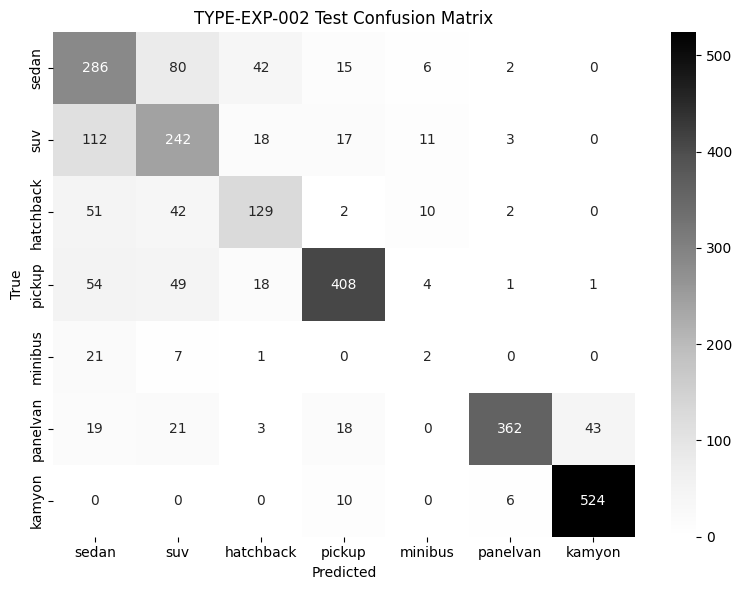

summary_json: /content/drive/MyDrive/anomali-road-safety-ai/runs/vehicle_type/TYPE-EXP-002/TYPE-EXP-002-summary.json
{
  "experiment_id": "TYPE-EXP-002",
  "best_backbone": "efficientnet_b0",
  "best_checkpoint": "/content/drive/MyDrive/anomali-road-safety-ai/models/checkpoints/vehicle_type/TYPE-EXP-002-efficientnet_b0-best.pth",
  "label_map": "/content/drive/MyDrive/anomali-road-safety-ai/models/checkpoints/vehicle_type/TYPE-EXP-002-label-map.json",
  "val_macro_f1": 0.6300940997199457,
  "val_accuracy": 0.7408248202799849,
  "test_macro_f1": 0.6311508676681911,
  "test_accuracy": 0.7392127176381529,
  "train_size": 12326,
  "val_size": 2643,
  "test_size": 2642,
  "class_counts_raw": {
    "sedan": 2872,
    "suv": 2683,
    "hatchback": 1573,
    "pickup": 3566,
    "minibus": 209,
    "panelvan": 3108,
    "kamyon": 3600
  },
  "class_counts_used": {
    "sedan": 2872,
    "suv": 2683,
    "hatchback": 1573,
    "pickup": 3566,
    "minibus": 209,
    "panelvan": 3108,
    "kamyon

In [ ]:
# Cell 11 — Test evaluation, confusion matrix, and exports
def load_checkpoint_model(checkpoint_path):
    ckpt = torch.load(checkpoint_path, map_location=device)
    model = build_model(ckpt['backbone']).to(device)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()
    return model, ckpt

best_model, best_ckpt = load_checkpoint_model(BEST_CHECKPOINT)
val_eval = evaluate_model(best_model, val_loader)
test_eval = evaluate_model(best_model, test_loader)

print('Validation macro-F1:', val_eval['macro_f1'], 'acc:', val_eval['accuracy'])
print('Test macro-F1:', test_eval['macro_f1'], 'acc:', test_eval['accuracy'])

report_dict = classification_report(
    test_eval['labels'], test_eval['preds'], labels=list(range(NUM_CLASSES)),
    target_names=FTR_TYPE_LABELS, output_dict=True, zero_division=0,
)
report_df = pd.DataFrame(report_dict).T
report_csv = DRIVE_RUN_ROOT / f'{EXP_ID}-test_classification_report.csv'
report_df.to_csv(report_csv)
display(report_df)

cm = confusion_matrix(test_eval['labels'], test_eval['preds'], labels=list(range(NUM_CLASSES)))
cm_csv = DRIVE_RUN_ROOT / f'{EXP_ID}-test_confusion_matrix.csv'
pd.DataFrame(cm, index=FTR_TYPE_LABELS, columns=FTR_TYPE_LABELS).to_csv(cm_csv)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greys', xticklabels=FTR_TYPE_LABELS, yticklabels=FTR_TYPE_LABELS)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'{EXP_ID} Test Confusion Matrix')
plt.tight_layout()
cm_png = DRIVE_RUN_ROOT / f'{EXP_ID}-test_confusion_matrix.png'
plt.savefig(cm_png, dpi=180)
plt.show()

def predictions_df(eval_result):
    rows = []
    for path, true_id, pred_id, probs in zip(eval_result['paths'], eval_result['labels'], eval_result['preds'], eval_result['probs']):
        top3 = np.argsort(probs)[-3:][::-1]
        rows.append({
            'image_path': path,
            'true_label': id_to_label[int(true_id)],
            'pred_label': id_to_label[int(pred_id)],
            'confidence': float(probs[int(pred_id)]),
            'margin': float(np.sort(probs)[-1] - np.sort(probs)[-2]) if len(probs) > 1 else float(probs[int(pred_id)]),
            'top3': json.dumps([{'label': id_to_label[int(i)], 'confidence': float(probs[int(i)])} for i in top3], ensure_ascii=False),
        })
    return pd.DataFrame(rows)

pred_csv = DRIVE_RUN_ROOT / f'{EXP_ID}-test_predictions.csv'
predictions_df(test_eval).to_csv(pred_csv, index=False)

label_map_json = DRIVE_CKPT_ROOT / f'{EXP_ID}-label-map.json'
label_map_json.write_text(json.dumps({'label_to_id': label_to_id, 'id_to_label': id_to_label, 'labels': FTR_TYPE_LABELS}, ensure_ascii=False, indent=2), encoding='utf-8')

summary_json = DRIVE_RUN_ROOT / f'{EXP_ID}-summary.json'
summary = {
    'experiment_id': EXP_ID,
    'best_backbone': BEST_BACKBONE,
    'best_checkpoint': str(BEST_CHECKPOINT),
    'label_map': str(label_map_json),
    'val_macro_f1': val_eval['macro_f1'],
    'val_accuracy': val_eval['accuracy'],
    'test_macro_f1': test_eval['macro_f1'],
    'test_accuracy': test_eval['accuracy'],
    'train_size': len(train_df),
    'val_size': len(val_df),
    'test_size': len(test_df),
    'class_counts_raw': metadata_df['ftr_type'].value_counts().reindex(FTR_TYPE_LABELS).fillna(0).astype(int).to_dict(),
    'class_counts_used': usable_df['ftr_type'].value_counts().reindex(FTR_TYPE_LABELS).fillna(0).astype(int).to_dict(),
    'source_x_class': pd.crosstab(metadata_df['source_dataset'], metadata_df['ftr_type']).reindex(columns=FTR_TYPE_LABELS, fill_value=0).to_dict(),
    'artifacts': {
        'metadata_csv': str(metadata_csv),
        'splits_csv': str(splits_csv),
        'backbone_summary_csv': str(summary_path),
        'classification_report_csv': str(report_csv),
        'confusion_matrix_csv': str(cm_csv),
        'confusion_matrix_png': str(cm_png),
        'test_predictions_csv': str(pred_csv),
        'label_map_json': str(label_map_json),
    },
}
summary_json.write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding='utf-8')
print('summary_json:', summary_json)
print(json.dumps(summary, ensure_ascii=False, indent=2)[:2500])

In [ ]:
# Cell 12 — Optional target ROI smoke inference from existing project crops
SMOKE_CROP_CANDIDATES = [
    PROJECT_ROOT / 'runs' / '_archive' / 'plate_ocr_v1_POCR-EXP-001-target-roi-crops' / 'sample_frames',
    PROJECT_ROOT / 'runs' / 'plate_ocr' / 'POCR-EXP-001-target-roi-crops' / 'sample_frames',
    LOCAL_ROOT / 'runs' / '_archive' / 'plate_ocr_v1_POCR-EXP-001-target-roi-crops' / 'sample_frames',
]

def predict_image(path):
    image = Image.open(path).convert('RGB')
    tensor = eval_tf(image).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = torch.softmax(best_model(tensor), dim=1).cpu().numpy().reshape(-1)
    top = int(np.argmax(probs))
    sorted_idx = np.argsort(probs)
    second = int(sorted_idx[-2]) if len(probs) > 1 else top
    return {
        'crop_uri': str(path),
        'pred_type': id_to_label[top],
        'confidence': float(probs[top]),
        'margin': float(probs[top] - probs[second]),
        'top3': json.dumps([{'label': id_to_label[int(idx)], 'confidence': float(probs[int(idx)])} for idx in sorted_idx[-3:][::-1]], ensure_ascii=False),
    }

smoke_dir = next((p for p in SMOKE_CROP_CANDIDATES if p.exists() and any(p.glob('*.jpg'))), None)
if smoke_dir is None:
    print('No target ROI crop folder found. Smoke inference skipped.')
else:
    crop_paths = sorted(smoke_dir.glob('*.jpg'))
    smoke_rows = [predict_image(p) for p in tqdm(crop_paths, desc='target ROI smoke')]
    smoke_df = pd.DataFrame(smoke_rows)
    smoke_csv = DRIVE_RUN_ROOT / f'{EXP_ID}-target_roi_smoke_predictions.csv'
    smoke_df.to_csv(smoke_csv, index=False)
    print('smoke_csv:', smoke_csv)
    display(smoke_df['pred_type'].value_counts().to_frame('count'))
    display(smoke_df.head(20))

No target ROI crop folder found. Smoke inference skipped.


In [ ]:
# Cell 13 — Markdown run report
report_md = DRIVE_RUN_ROOT / f'{EXP_ID}-run_summary.md'
lines = [
    f'# {EXP_ID} Multi-source Vehicle Type Classifier Summary',
    '',
    f'- Best backbone: `{BEST_BACKBONE}`',
    f'- Best checkpoint: `{BEST_CHECKPOINT}`',
    f'- Validation macro-F1: `{val_eval["macro_f1"]:.4f}`',
    f'- Validation accuracy: `{val_eval["accuracy"]:.4f}`',
    f'- Test macro-F1: `{test_eval["macro_f1"]:.4f}`',
    f'- Test accuracy: `{test_eval["accuracy"]:.4f}`',
    f'- Train/val/test: `{len(train_df)}/{len(val_df)}/{len(test_df)}`',
    '',
    '## FTR Labels',
    '',
    ', '.join(f'`{x}`' for x in FTR_TYPE_LABELS),
    '',
    '## Data Sources',
    '',
    '- Stanford Cars: model-name based conservative type mapping.',
    '- Car Body Type Kaggle: body-style class folder mapping.',
    '- MIO-TCD classification subset/mirror: pickup/work-van/truck support.',
    '- Manual FTR folders: direct label folders for missing/weak classes.',
    '',
    '## Class Counts Used',
    '',
]
for label, count in usable_df['ftr_type'].value_counts().reindex(FTR_TYPE_LABELS).fillna(0).astype(int).items():
    lines.append(f'- `{label}`: {count}')
lines.extend([
    '',
    '## Important Notes',
    '',
    '- This model is a candidate for FTR `arac_bilgisi.tip`, not automatically final.',
    '- Final promotion still requires target ROI smoke inference and manual review on local demo videos.',
    '- `minibus` vs `panelvan` and truck-like classes must be reviewed carefully because source datasets use different taxonomies.',
    '- If any class F1 is below acceptance threshold, add targeted manual/external data before runtime integration.',
    '',
    '## Artifacts',
    '',
    f'- Summary JSON: `{summary_json}`',
    f'- Label map: `{label_map_json}`',
    f'- Classification report CSV: `{report_csv}`',
    f'- Confusion matrix PNG: `{cm_png}`',
])
report_md.write_text('\n'.join(lines), encoding='utf-8')
print('report_md:', report_md)
print('\n'.join(lines[:80]))

report_md: /content/drive/MyDrive/anomali-road-safety-ai/runs/vehicle_type/TYPE-EXP-002/TYPE-EXP-002-run_summary.md
# TYPE-EXP-002 Multi-source Vehicle Type Classifier Summary

- Best backbone: `efficientnet_b0`
- Best checkpoint: `/content/drive/MyDrive/anomali-road-safety-ai/models/checkpoints/vehicle_type/TYPE-EXP-002-efficientnet_b0-best.pth`
- Validation macro-F1: `0.6301`
- Validation accuracy: `0.7408`
- Test macro-F1: `0.6312`
- Test accuracy: `0.7392`
- Train/val/test: `12326/2643/2642`

## FTR Labels

`sedan`, `suv`, `hatchback`, `pickup`, `minibus`, `panelvan`, `kamyon`

## Data Sources

- Stanford Cars: model-name based conservative type mapping.
- Car Body Type Kaggle: body-style class folder mapping.
- MIO-TCD classification subset/mirror: pickup/work-van/truck support.
- Manual FTR folders: direct label folders for missing/weak classes.

## Class Counts Used

- `sedan`: 2872
- `suv`: 2683
- `hatchback`: 1573
- `pickup`: 3566
- `minibus`: 209
- `panelvan`: 3108
- `kamyon`